# Feature Extraction Showcase

This notebook demonstrates the end-to-end feature engineering pipeline for speech pathology classification.

It covers:
- running extraction via `FeatureOptions`
- inspecting the generated multi-table outputs
- basic quality checks and quick exploratory plots

In [17]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..")

from src.features import FeatureOptions, load_feature_tables, summarize_feature_tables

In [18]:
# Configure extraction/loading behavior
opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=42,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    max_samples_per_class=200,  # Speed-up for testing; set None for full run.
 )

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [19]:
# Build missing tables if needed, otherwise load cached outputs
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)
summary = summarize_feature_tables(tables)
summary

{'num_samples': 1214,
 'num_acoustic_rows': 1214,
 'num_multifractal_rows': 1214,
 'num_opensmile_rows': 1214,
 'feature_status_counts': {'ok': 1214},
 'acoustic_status_counts': {'ok': 1214},
 'multifractal_status_counts': {'ok': 1214},
 'opensmile_status_counts': {'ok': 1214},
 'split_counts': {'train': 931, 'test': 162, 'val': 121}}

## Inspect generated tables

The pipeline creates separate tables for metadata/core status, acoustic features, multifractal features, and splits.

In [20]:
for name, df in tables.items():
    print(f"{name}: shape={df.shape}")

core_df = tables["core"]
acoustic_df = tables["acoustic"]
multifractal_df = tables["multifractal"]
opensmile_df = tables["opensmile"]
splits_df = tables.get("splits", pd.DataFrame())

core: shape=(1214, 18)
acoustic: shape=(1214, 87)
multifractal: shape=(1214, 17)
opensmile: shape=(1214, 91)
splits: shape=(1214, 3)


In [21]:
core_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,is_overlap_speaker,is_overlap_speaker_id,wav_path,feature_status,feature_error,audio_sample_rate,audio_num_samples,audio_duration_seconds
0,Morbus Parkinson::1580::vowels::a_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_h,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,NaN,50000,28864,0.57728
1,Morbus Parkinson::1580::vowels::a_l,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_l,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,NaN,50000,36123,0.72246
2,Morbus Parkinson::1580::vowels::a_lhl,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_lhl,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,NaN,50000,45391,0.90782
3,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,NaN,50000,36123,0.72246
4,Morbus Parkinson::1580::vowels::i_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,i_h,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,NaN,50000,38251,0.76502


In [22]:
acoustic_df.head()

,sample_key,acoustic_status,acoustic_error,ac_time_energy,ac_time_abs_mean,ac_time_peak,ac_time_crest_factor,ac_rms_mean,ac_rms_std,ac_rms_min,...,ac_mfcc12_delta_mean,ac_mfcc12_delta_std,ac_mfcc13_mean,ac_mfcc13_std,ac_mfcc13_delta_mean,ac_mfcc13_delta_std,ac_f0_mean,ac_f0_std,ac_f0_min,ac_f0_max
0,Morbus Parkinson::1580::vowels::a_h,ok,NaN,0.136878,0.311797,1.0,2.702923,0.361989,0.052316,0.234498,...,-0.083467,0.872922,-5.545632,4.178472,-0.156419,0.636762,179.013791,29.165446,94.379888,197.760774
1,Morbus Parkinson::1580::vowels::a_l,ok,NaN,0.110912,0.268923,1.0,3.002687,0.329604,0.023253,0.230419,...,0.030101,0.584257,-5.779543,4.559168,-0.134036,0.645118,160.845648,2.690300,152.663472,165.905134
2,Morbus Parkinson::1580::vowels::a_lhl,ok,NaN,0.104339,0.260001,1.0,3.095821,0.318222,0.045023,0.186317,...,-0.030593,1.023712,-9.565076,7.280129,-0.147624,0.698419,177.240006,13.103415,160.138585,204.448509
3,Morbus Parkinson::1580::vowels::a_n,ok,NaN,0.110912,0.268923,1.0,3.002687,0.329604,0.023253,0.230419,...,0.030101,0.584257,-5.779543,4.559168,-0.134036,0.645118,160.845648,2.690300,152.663472,165.905134
4,Morbus Parkinson::1580::vowels::i_h,ok,NaN,0.260261,0.447552,1.0,1.960178,0.504964,0.034980,0.401630,...,0.122696,1.029977,-26.474308,5.875587,-0.108147,0.974978,190.345780,4.673139,184.317933,205.185007


In [23]:
multifractal_df.head()

,sample_key,mf_status,mf_error,mf_hq_mean,mf_hq_std,mf_hq_min,mf_hq_max,mf_tau_mean,mf_tau_std,mf_alpha_mean,mf_alpha_std,mf_spectrum_width,mf_spectrum_peak_alpha,mf_spectrum_peak_f,mf_spectrum_asymmetry,mf_num_scales,mf_num_q
0,Morbus Parkinson::1580::vowels::a_h,ok,NaN,0.763622,0.194740,0.549508,1.080395,-1.629599,2.675148,0.835938,0.319092,0.792299,0.615091,0.977071,0.182400,20,10
1,Morbus Parkinson::1580::vowels::a_l,ok,NaN,0.754653,0.169290,0.559381,1.035577,-1.550596,2.617846,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10
2,Morbus Parkinson::1580::vowels::a_lhl,ok,NaN,0.734180,0.211263,0.493038,1.068850,-1.687689,2.574736,0.800038,0.343014,0.854544,0.572759,0.967594,0.208532,20,10
3,Morbus Parkinson::1580::vowels::a_n,ok,NaN,0.754653,0.169290,0.559381,1.035577,-1.550596,2.617846,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10
4,Morbus Parkinson::1580::vowels::i_h,ok,NaN,0.820211,0.130337,0.664646,1.035104,-1.426205,2.792983,0.862010,0.228141,0.596956,0.724345,0.974918,0.244982,20,10


In [24]:
opensmile_df.head()

,sample_key,opensmile_status,opensmile_error,os_F0semitoneFrom27.5Hz_sma3nz_amean,os_F0semitoneFrom27.5Hz_sma3nz_stddevNorm,os_F0semitoneFrom27.5Hz_sma3nz_percentile20.0,os_F0semitoneFrom27.5Hz_sma3nz_percentile50.0,os_F0semitoneFrom27.5Hz_sma3nz_percentile80.0,os_F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,os_F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,os_slopeUV0-500_sma3nz_amean,os_slopeUV500-1500_sma3nz_amean,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp
0,Morbus Parkinson::1580::vowels::a_h,ok,NaN,33.312897,0.012536,32.929157,33.327755,33.685112,0.755955,7.509574,...,0.0,0.0,0.0,0.000000,2.000000,0.49,0.0,0.0,0.0,-12.509556
1,Morbus Parkinson::1580::vowels::a_l,ok,NaN,30.619734,0.007817,30.419205,30.542192,30.879210,0.460005,6.967229,...,0.0,0.0,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905
2,Morbus Parkinson::1580::vowels::a_lhl,ok,NaN,32.308372,0.039132,31.136822,31.840227,33.953823,2.817001,15.228954,...,0.0,0.0,0.0,1.123595,1.204819,0.82,0.0,0.0,0.0,-13.171670
3,Morbus Parkinson::1580::vowels::a_n,ok,NaN,30.619734,0.007817,30.419205,30.542192,30.879210,0.460005,6.967229,...,0.0,0.0,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905
4,Morbus Parkinson::1580::vowels::i_h,ok,NaN,33.372044,0.009419,33.148670,33.305401,33.536335,0.387665,6.105676,...,0.0,0.0,0.0,4.000000,1.449275,0.68,0.0,0.0,0.0,-10.455112


## Join features for modeling

Join on `sample_key` to obtain one model-ready view while preserving separate storage tables.

In [25]:
model_df = core_df.merge(acoustic_df, on="sample_key", how="left")
model_df = model_df.merge(multifractal_df, on="sample_key", how="left")
model_df = model_df.merge(opensmile_df, on="sample_key", how="left")

if not splits_df.empty:
    model_df = model_df.merge(splits_df, on="sample_key", how="left")

model_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp,split,split_seed
0,Morbus Parkinson::1580::vowels::a_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_h,m,...,0.0,0.000000,2.000000,0.49,0.0,0.0,0.0,-12.509556,train,42
1,Morbus Parkinson::1580::vowels::a_l,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_l,m,...,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905,train,42
2,Morbus Parkinson::1580::vowels::a_lhl,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_lhl,m,...,0.0,1.123595,1.204819,0.82,0.0,0.0,0.0,-13.171670,train,42
3,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,...,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905,train,42
4,Morbus Parkinson::1580::vowels::i_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,i_h,m,...,0.0,4.000000,1.449275,0.68,0.0,0.0,0.0,-10.455112,train,42


In [ ]:
print(f"{core_df.columns=}")
print(f"{acoustic_df.columns=}")
print(f"{multifractal_df.columns=}")
print(f"{opensmile_df.columns=}")

core_df.columns=Index(['sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id',
       'pathology_de', 'pathology_en', 'is_healthy', 'modality', 'token',
       'sex', 'is_overlap_speaker', 'is_overlap_speaker_id', 'wav_path',
       'feature_status', 'feature_error', 'audio_sample_rate',
       'audio_num_samples', 'audio_duration_seconds'],
      dtype='str')
acoustic_df.columns=Index(['sample_key', 'acoustic_status', 'acoustic_error', 'ac_time_energy',
       'ac_time_abs_mean', 'ac_time_peak', 'ac_time_crest_factor',
       'ac_rms_mean', 'ac_rms_std', 'ac_rms_min', 'ac_rms_max', 'ac_zcr_mean',
       'ac_zcr_std', 'ac_zcr_min', 'ac_zcr_max', 'ac_spec_centroid_mean',
       'ac_spec_centroid_std', 'ac_spec_centroid_min', 'ac_spec_centroid_max',
       'ac_spec_bandwidth_mean', 'ac_spec_bandwidth_std',
       'ac_spec_bandwidth_min', 'ac_spec_bandwidth_max',
       'ac_spec_rolloff_mean', 'ac_spec_rolloff_std', 'ac_spec_rolloff_min',
       'ac_spec_rolloff_max', 'ac_spec_

In [27]:
# Basic quality checks
status_cols = [c for c in ["feature_status", "acoustic_status", "mf_status"] if c in model_df.columns]
for col in status_cols:
    print(f"\n{col}\n", model_df[col].value_counts(dropna=False))

print("\nMissingness (top 20 columns):")
display(model_df.isna().mean().sort_values(ascending=False).head(20))


feature_status
 feature_status
ok    1214
Name: count, dtype: int64

acoustic_status
 acoustic_status
ok    1214
Name: count, dtype: int64

mf_status
 mf_status
ok    1214
Name: count, dtype: int64

Missingness (top 20 columns):


feature_error            1.0
acoustic_error           1.0
opensmile_error          1.0
mf_error                 1.0
speaker_id               0.0
recording_id             0.0
pathology_de             0.0
pathology_en             0.0
token                    0.0
sex                      0.0
is_healthy               0.0
modality                 0.0
is_overlap_speaker_id    0.0
is_overlap_speaker       0.0
feature_status           0.0
wav_path                 0.0
audio_sample_rate        0.0
audio_num_samples        0.0
sample_key               0.0
duplicate_class_key      0.0
dtype: float64

## Quick exploratory plots

These are lightweight sanity checks to visualize class balance and a few extracted features.

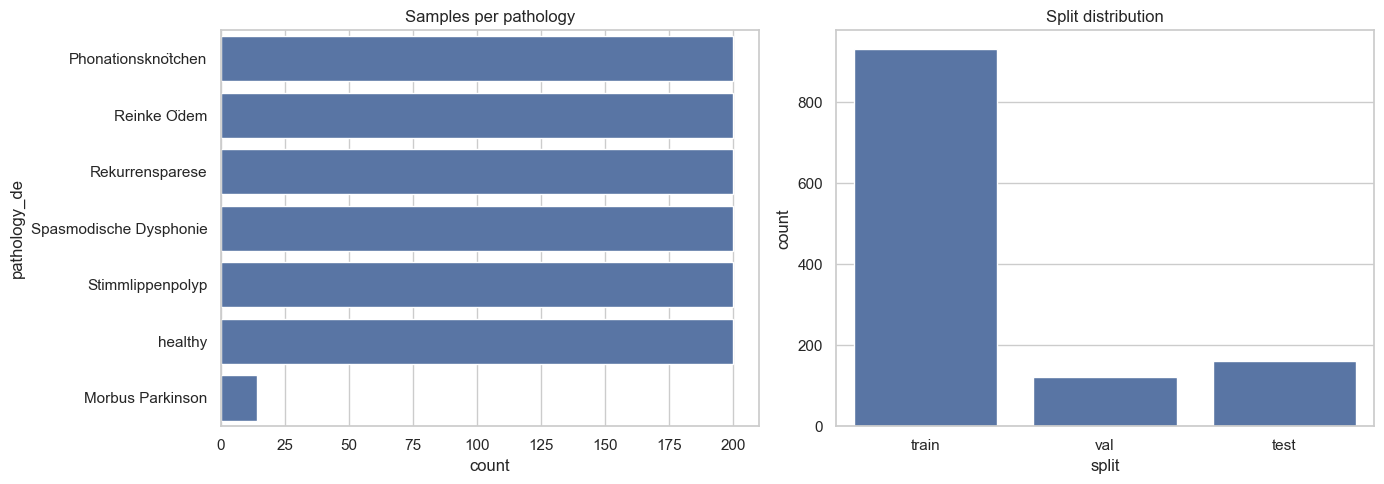

In [28]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if "pathology_de" in model_df.columns:
    order = model_df["pathology_de"].value_counts().index
    sns.countplot(data=model_df, y="pathology_de", order=order, ax=ax[0])
    ax[0].set_title("Samples per pathology")

if "split" in model_df.columns:
    sns.countplot(data=model_df, x="split", order=["train", "val", "test"], ax=ax[1])
    ax[1].set_title("Split distribution")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()

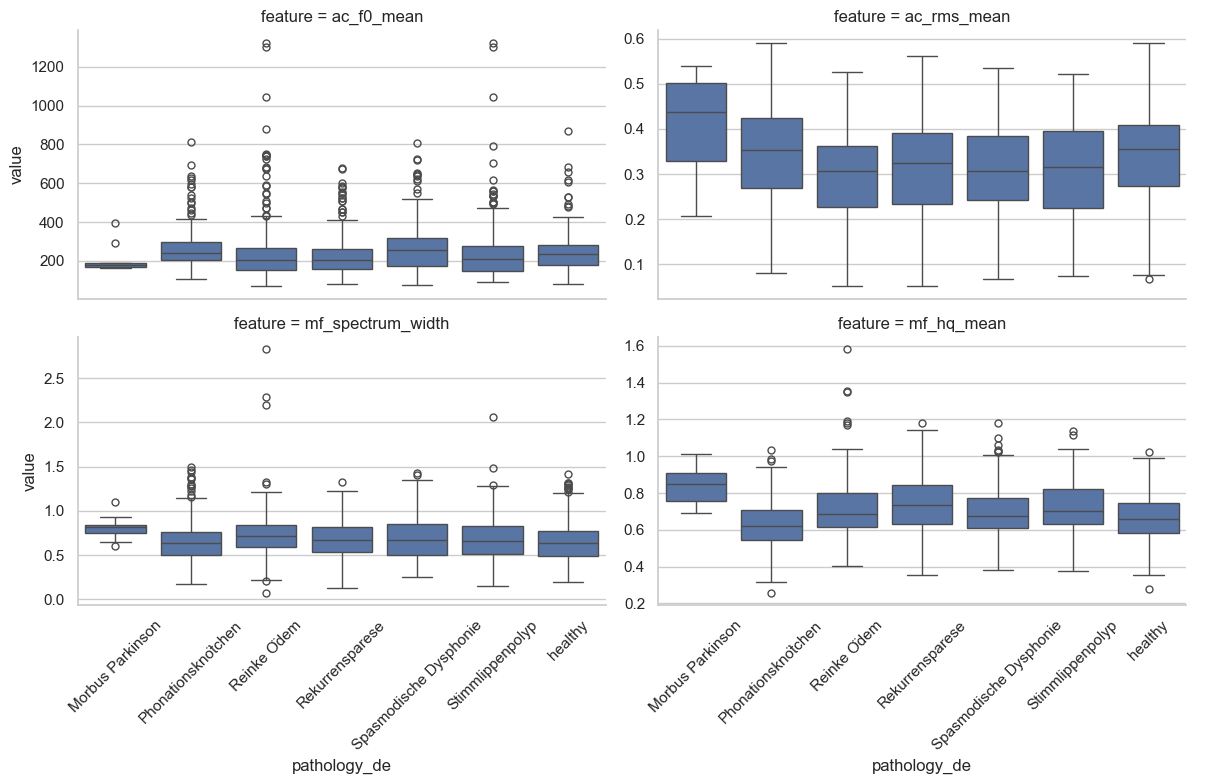

In [29]:
candidate_features = ["ac_f0_mean", "ac_rms_mean", "mf_spectrum_width", "mf_hq_mean"]
existing = [c for c in candidate_features if c in model_df.columns]

if existing and "pathology_de" in model_df.columns:
    plot_df = model_df[["pathology_de", *existing]].copy()
    melted = plot_df.melt(id_vars="pathology_de", var_name="feature", value_name="value")

    g = sns.catplot(
        data=melted,
        x="pathology_de",
        y="value",
        col="feature",
        col_wrap=2,
        kind="box",
        sharey=False,
        height=4,
        aspect=1.5,
    )
    for axis in g.axes.flatten():
        axis.tick_params(axis="x", rotation=45)
    g.fig.tight_layout()
    plt.show()
else:
    print("No candidate columns found yet for feature-by-pathology plot.")

## Persist a model-ready snapshot (optional)

Use this cell if you want a single joined table for rapid prototyping.

In [30]:
out_path = Path("..") / "data" / "processed" / "features" / "model_table_snapshot.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(out_path, index=False)
print(f"Wrote: {out_path.resolve()}")

Wrote: G:\Projects\multifractal-speech-analysis\data\processed\features\model_table_snapshot.csv
